In [12]:
# Adverse Drug Reaction (ADR) Data Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load & Inspect Data

df = pd.read_csv("/content/fda_adverse_events_2015_2026_CLEAN.csv",
                 encoding="latin1", low_memory=False)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

# 2. KPIs

total_reports = len(df)
serious_reports = df[df['serious'] == 'Yes'].shape[0]
suspected_drugs = df['manufacturer'].nunique()
reporting_countries = df['country'].nunique()

print("Total ADR Reports:", total_reports)
print("Serious ADR Reports:", serious_reports,
      f"({round(serious_reports/total_reports*100,2)}%)")
print("Suspected Drugs:", suspected_drugs)
print("Reporting Countries:", reporting_countries)

Shape: (528000, 30)
Columns: ['report_id', 'receive_date', 'year', 'month', 'quarter', 'serious', 'serious_flags', 'is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling', 'reactions', 'primary_reaction', 'reaction_outcomes', 'patient_recovered', 'num_reactions', 'suspect_drug', 'brand_name', 'drug_route', 'drug_indication', 'manufacturer', 'pharm_class', 'num_drugs', 'drug_count_category', 'patient_age_years', 'age_group', 'patient_sex', 'patient_weight_kg', 'country', 'report_age_days']
   report_id receive_date  year  month quarter serious    serious_flags  \
0   10004718   2015-02-11  2015      2  2015Q1     Yes  Hospitalization   
1   10004926   2015-02-13  2015      2  2015Q1     Yes  Hospitalization   
2   10005223   2015-02-19  2015      2  2015Q1     Yes  Hospitalization   
3   10005378   2015-02-17  2015      2  2015Q1     Yes  Hospitalization   
4   10005980   2015-02-21  2015      2  2015Q1     Yes              NaN   

   is_fatal  is_hospitalized  is_life_threat  .

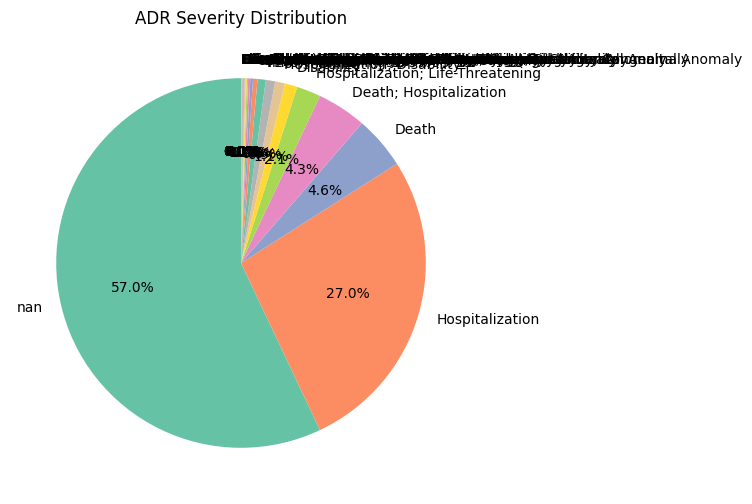

/tmp/ipykernel_812/2240969674.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=soc_counts.values, y=soc_counts.index, palette="viridis")


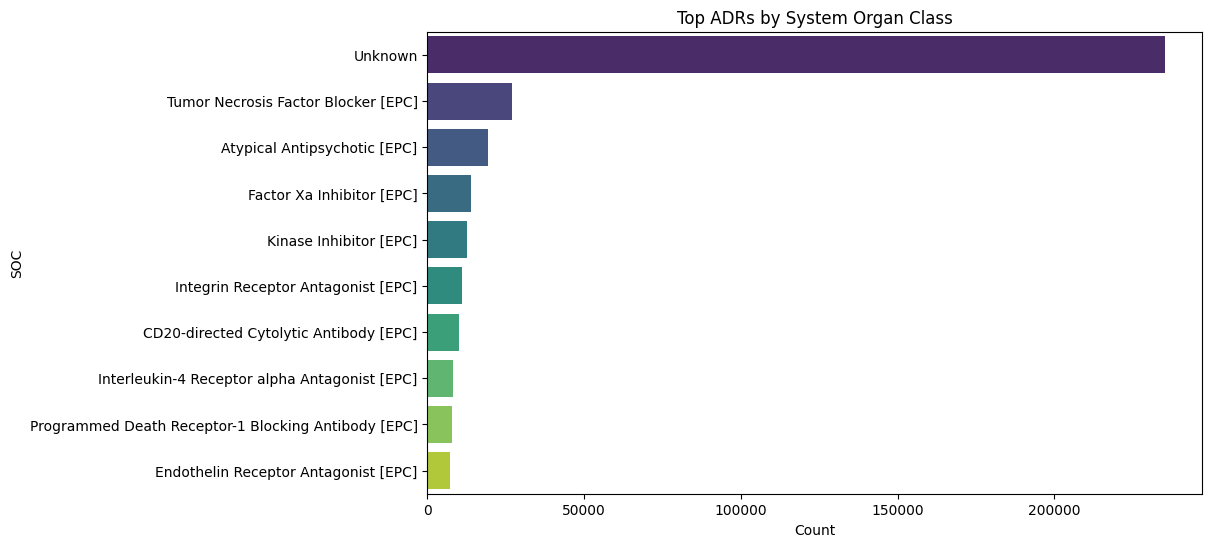

In [13]:
# 3. Severity Distribution

severity_counts = df['serious_flags'].value_counts(dropna=False)

plt.figure(figsize=(6,6))
plt.pie(severity_counts, labels=severity_counts.index,
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
plt.title("ADR Severity Distribution")
plt.show()

# 4. ADR by System Organ Class (SOC)

soc_counts = df['pharm_class'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=soc_counts.values, y=soc_counts.index, palette="viridis")
plt.title("Top ADRs by System Organ Class")
plt.xlabel("Count")
plt.ylabel("SOC")
plt.show()

/tmp/ipykernel_812/600908869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=serious_drugs.values, y=serious_drugs.index, palette="Reds")


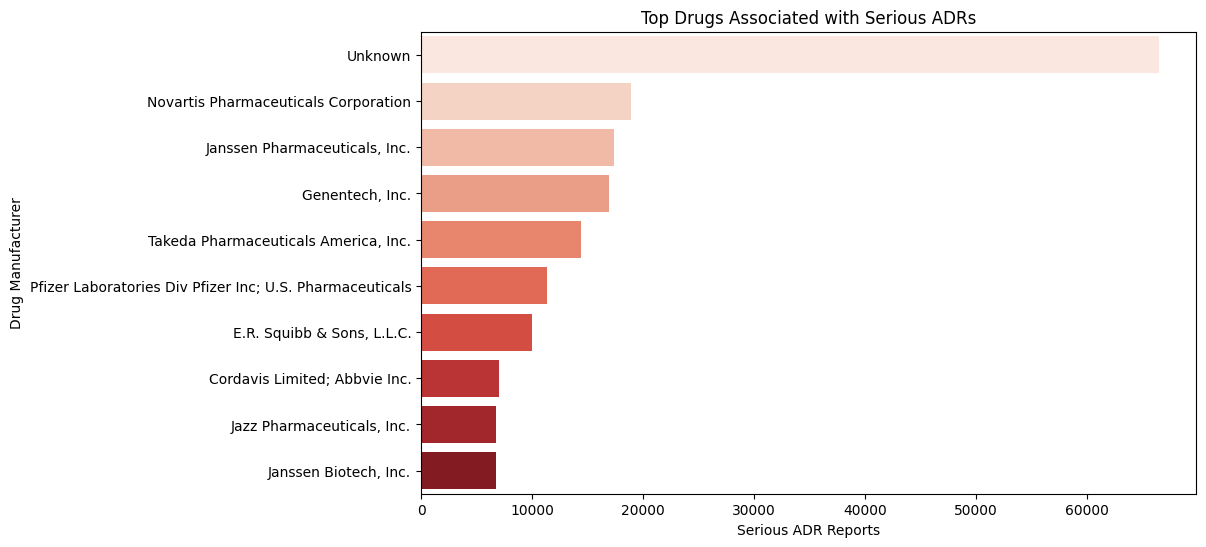

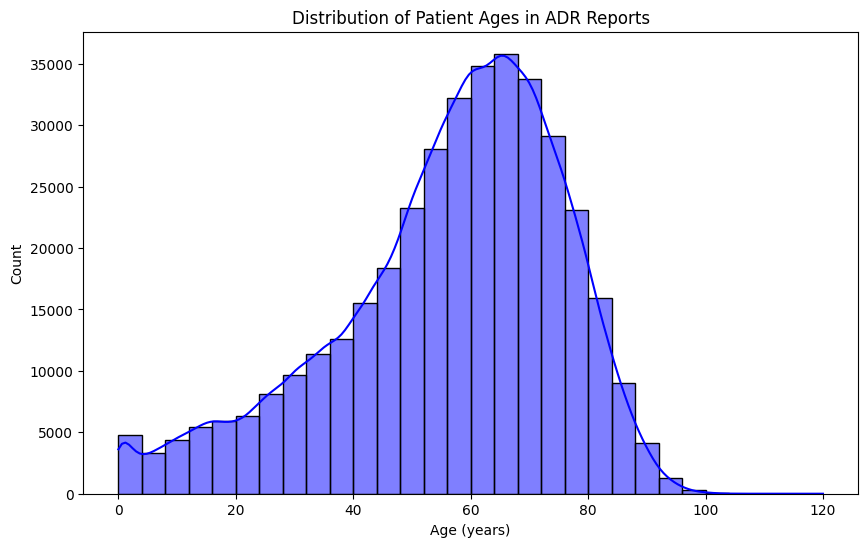

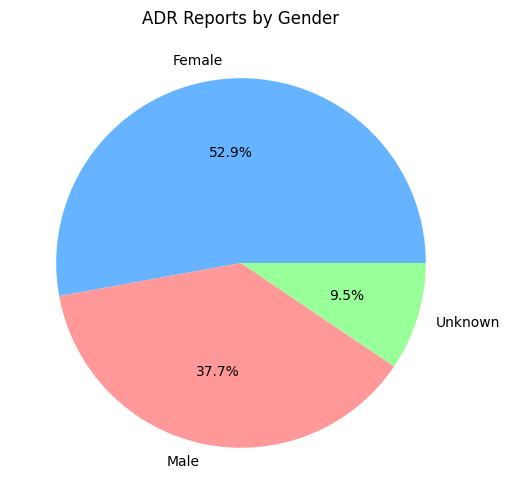

In [14]:
# 5. Serious ADRs by Drug

serious_drugs = df[df['serious'] == 'Yes']['manufacturer'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=serious_drugs.values, y=serious_drugs.index, palette="Reds")
plt.title("Top Drugs Associated with Serious ADRs")
plt.xlabel("Serious ADR Reports")
plt.ylabel("Drug Manufacturer")
plt.show()

# 6. Demographics

# Age distribution
plt.figure(figsize=(10,6))
sns.histplot(df['patient_age_years'].dropna(), bins=30, kde=True, color="blue")
plt.title("Distribution of Patient Ages in ADR Reports")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.show()

# Gender distribution
gender_counts = df['patient_sex'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index,
        autopct='%1.1f%%', colors=['#66b3ff','#ff9999','#99ff99'])
plt.title("ADR Reports by Gender")
plt.show()

/tmp/ipykernel_812/3343352206.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette="coolwarm")


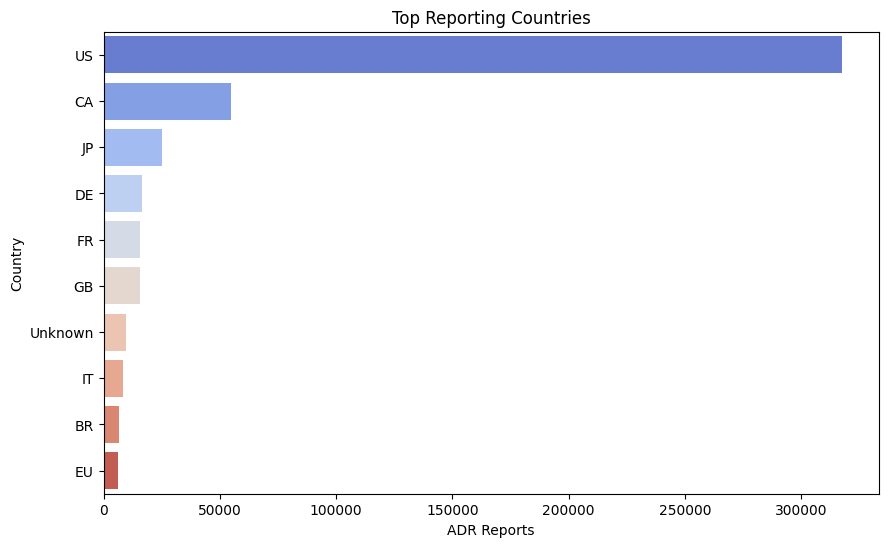

/tmp/ipykernel_812/3343352206.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=signal_df['PRR'], y=signal_df.index, palette="magma")


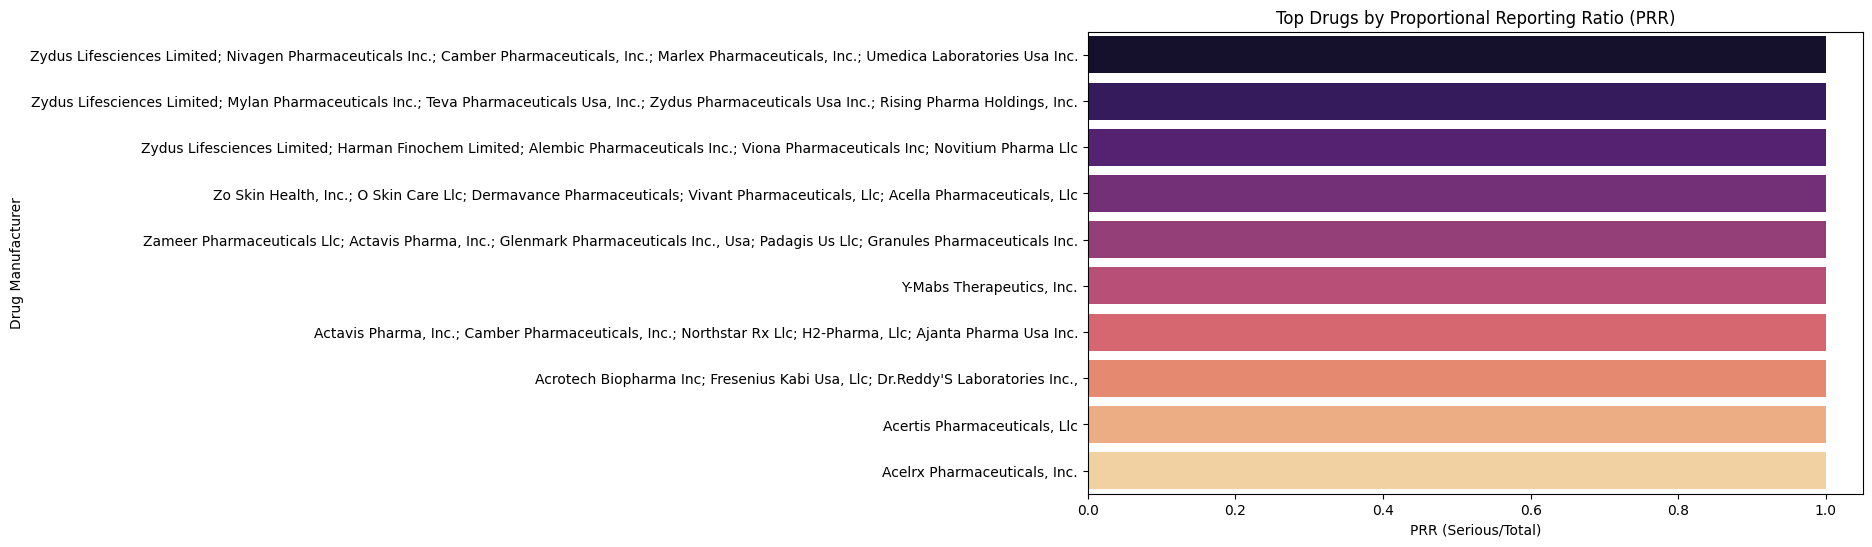

In [15]:
# 7. Country Trends

country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=country_counts.values, y=country_counts.index, palette="coolwarm")
plt.title("Top Reporting Countries")
plt.xlabel("ADR Reports")
plt.ylabel("Country")
plt.show()


# 8. Signal Detection (PRR/ROR) proportional reporting ratio

drug_serious = df[df['serious'] == 'Yes']['manufacturer'].value_counts()
drug_total = df['manufacturer'].value_counts()

signal_df = pd.DataFrame({
    'TotalReports': drug_total,
    'SeriousReports': drug_serious
}).fillna(0)

signal_df['PRR'] = signal_df['SeriousReports'] / signal_df['TotalReports']
signal_df = signal_df.sort_values('PRR', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=signal_df['PRR'], y=signal_df.index, palette="magma")
plt.title("Top Drugs by Proportional Reporting Ratio (PRR)")
plt.xlabel("PRR (Serious/Total)")
plt.ylabel("Drug Manufacturer")
plt.show()

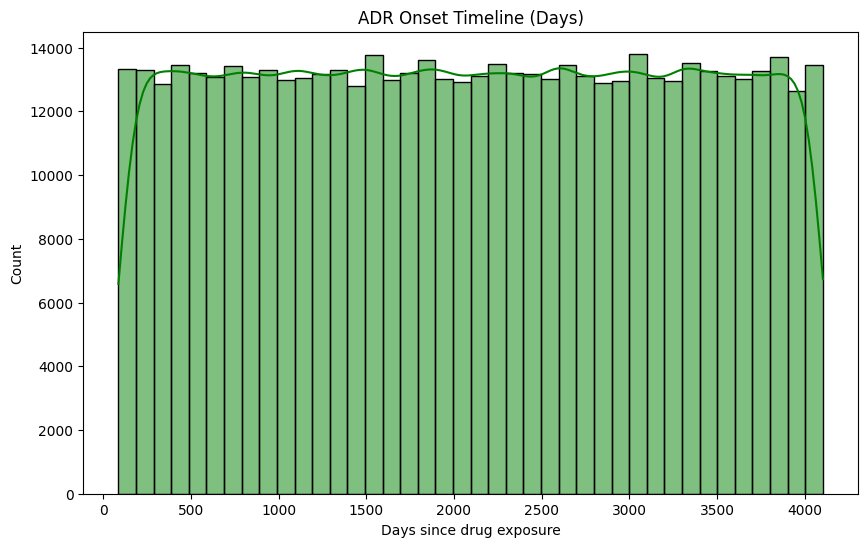

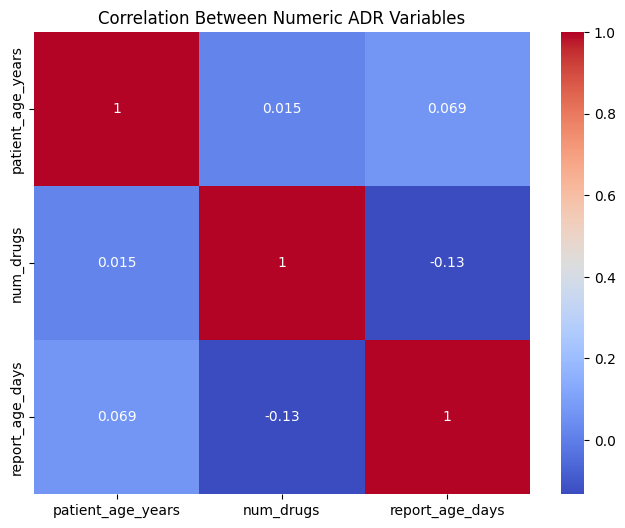

In [16]:
# 9. Onset Timeline

plt.figure(figsize=(10,6))
sns.histplot(df['report_age_days'].dropna(), bins=40, kde=True, color="green")
plt.title("ADR Onset Timeline (Days)")
plt.xlabel("Days since drug exposure")
plt.ylabel("Count")
plt.show()

# 10. Correlation Heatmap

numeric_cols = ['patient_age_years','num_drugs','report_age_days']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric ADR Variables")
plt.show()

<Figure size 1000x600 with 0 Axes>

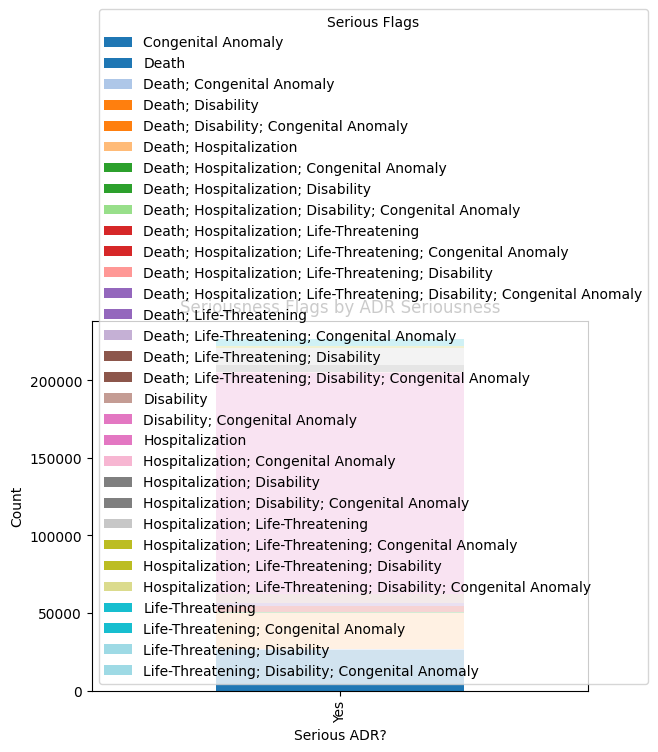

<Figure size 1000x600 with 0 Axes>

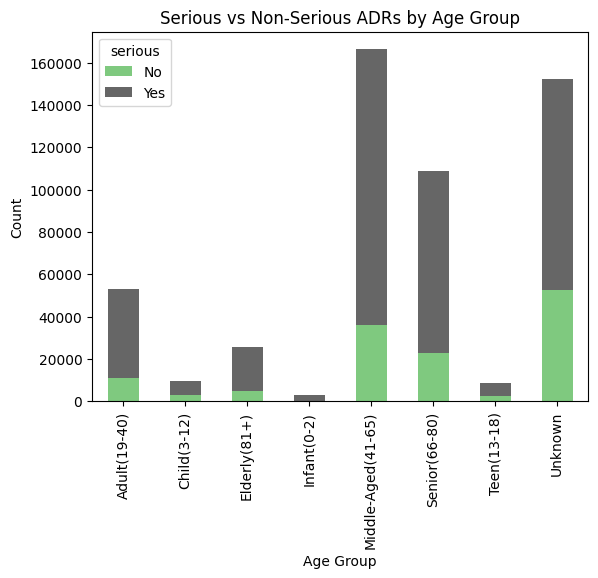

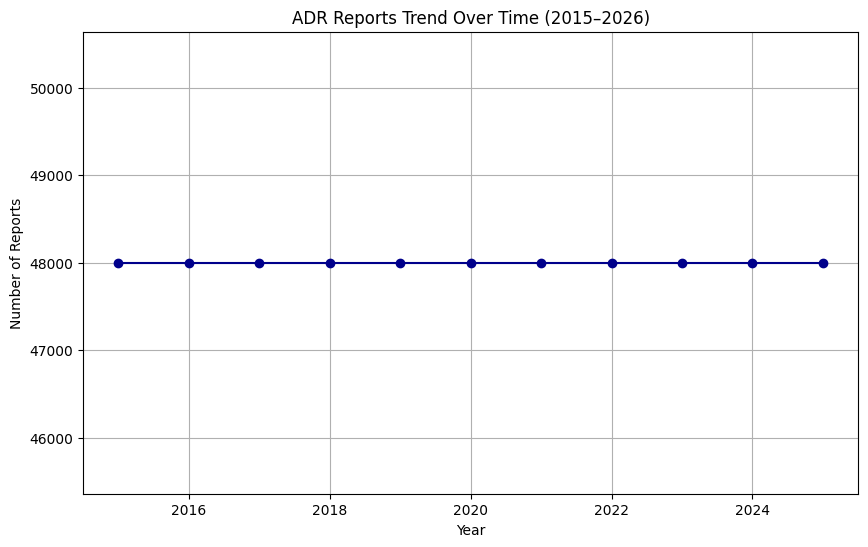

In [17]:
# 11. Serious vs Non-Serious Outcomes

serious_flags = df.groupby('serious')['serious_flags'].value_counts().unstack().fillna(0)

plt.figure(figsize=(10,6))
serious_flags.plot(kind='bar', stacked=True, colormap="tab20")
plt.title("Seriousness Flags by ADR Seriousness")
plt.xlabel("Serious ADR?")
plt.ylabel("Count")
plt.legend(title="Serious Flags")
plt.show()

# 12. Age Group vs Serious ADRs

age_serious = df.groupby('age_group')['serious'].value_counts().unstack().fillna(0)

plt.figure(figsize=(10,6))
age_serious.plot(kind='bar', stacked=True, colormap="Accent")
plt.title("Serious vs Non-Serious ADRs by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

# 13. Trend Over Time

reports_per_year = df.groupby('year')['report_id'].count()

plt.figure(figsize=(10,6))
reports_per_year.plot(kind='line', marker='o', color='darkblue')
plt.title("ADR Reports Trend Over Time (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Number of Reports")
plt.grid(True)
plt.show()


/tmp/ipykernel_812/3558685463.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fatal_drugs.values, y=fatal_drugs.index, palette="dark:red")


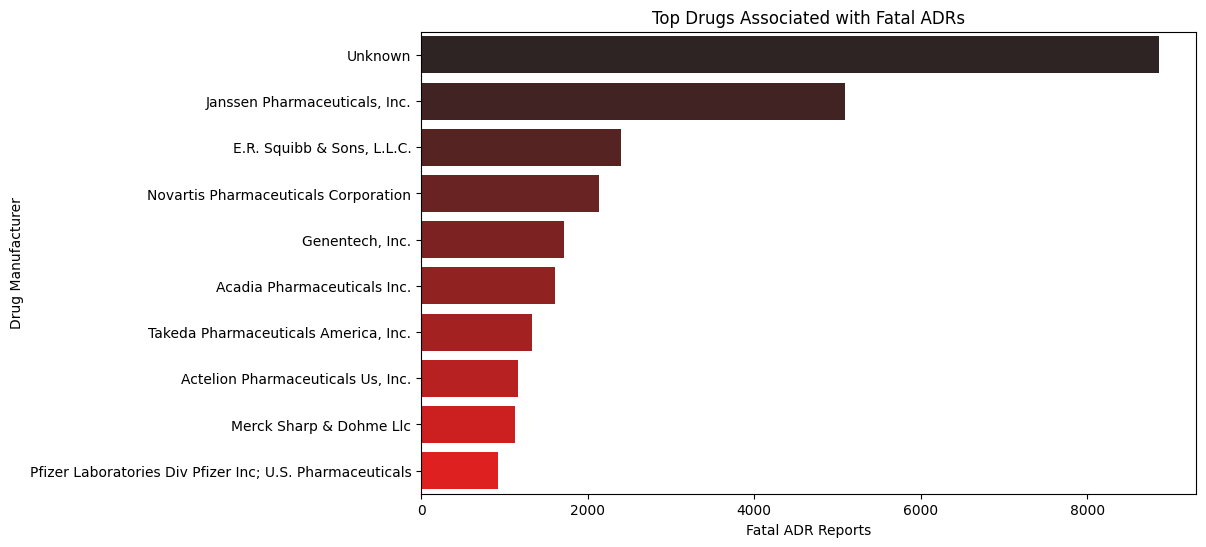

/tmp/ipykernel_812/3558685463.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hospitalized_counts.values, y=hospitalized_counts.index, palette="Blues")


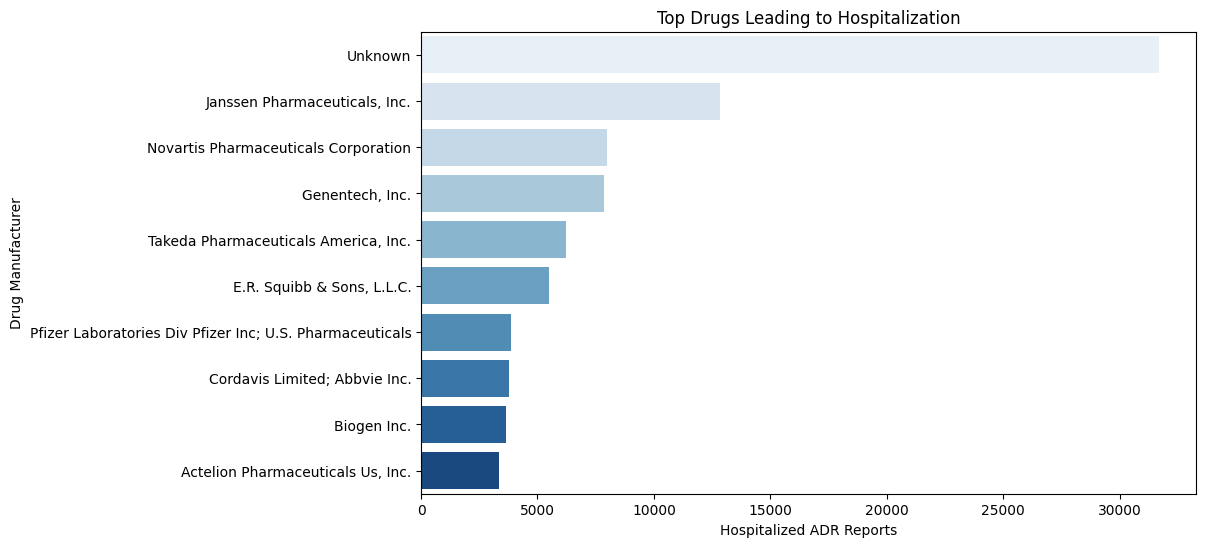

In [18]:
# 14. Fatal ADRs by Drug

fatal_drugs = df[df['is_fatal'] == True]['manufacturer'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=fatal_drugs.values, y=fatal_drugs.index, palette="dark:red")
plt.title("Top Drugs Associated with Fatal ADRs")
plt.xlabel("Fatal ADR Reports")
plt.ylabel("Drug Manufacturer")
plt.show()

# 15. Hospitalization Analysis

hospitalized_counts = df[df['is_hospitalized'] == True]['manufacturer'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=hospitalized_counts.values, y=hospitalized_counts.index, palette="Blues")
plt.title("Top Drugs Leading to Hospitalization")
plt.xlabel("Hospitalized ADR Reports")
plt.ylabel("Drug Manufacturer")
plt.show()
